In [1]:
%load_ext kedro.ipython

[04/13/25 15:55:27] INFO     Using                                                                  ]8;id=981180;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=725864;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\site-packages\kedro\framework\project\__init__.py#249\249]8;;\
                             'C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\site-packa                
                             ges\kedro\framework\project\rich_logging.yml' as logging                              
                             configuration.                                                                        

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=721844;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=769912;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\site-packages\kedro\ipython\__init__.py#58\58]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=65893;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=975755;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\site-packages\kedro\ipython\__init__.py#60\60]8;;\

                    INFO     Resolved project path as:                                              ]8;id=935166;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=460004;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\site-packages\kedro\ipython\__init__.py#175\175]8;;\
                             C:\Users\matia\OneDrive\Escritorio\ProyectoStarcraft\ProyectoMineria.                 
                             To set a different path, run '%reload_kedro <project_root>'                           

[04/13/25 15:55:35] INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=575142;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=261993;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\site-packages\kedro_telemetry\plugin.py#233\233]8;;\
                             the product. No personal data or IP addresses are stored on our side. If              
                             you want to opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK`              
                             environment variables, or create a `.telemetry` file in the current                   
                             working directory with the contents `consent: false`. Read more at                    
                             https://docs.kedro.org/en/stable/configuration/telemetry.html                         

                    INFO     Kedro project starcraft                                                ]8;id=351664;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=108353;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\site-packages\kedro\ipython\__init__.py#141\141]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=697137;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=954720;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\site-packages\kedro\ipython\__init__.py#142\142]8;;\
                             'pipelines'                                                                           

In [2]:
catalog


{'starcraft_duoc': "kedro_datasets.pandas.csv_dataset.CSVDataset(filepath=PurePosixPath('C:/Users/matia/OneDrive/Escritorio/ProyectoStarcraft/ProyectoMineria/data/01_raw/starcraft_duoc.csv'), "
                   "protocol='file', load_args={'delimiter': ';', "
                   "'on_bad_lines': 'skip'}, save_args={'index': False})",
 'nulos_data': "kedro_datasets.pandas.csv_dataset.CSVDataset(filepath=PurePosixPath('C:/Users/matia/OneDrive/Escritorio/ProyectoStarcraft/ProyectoMineria/data/02_intermediate/nulos_data.csv'), "
               "protocol='file', load_args={}, save_args={'index': False})",
 'imputed_data': "kedro_datasets.pandas.csv_dataset.CSVDataset(filepath=PurePosixPath('C:/Users/matia/OneDrive/Escritorio/ProyectoStarcraft/ProyectoMineria/data/02_intermediate/imputed_data.csv'), "
                 "protocol='file', load_args={}, save_args={'index': False})",
 'mapped_data': "kedro_datasets.pandas.csv_dataset.CSVDataset(filepath=PurePosixPath('C:/Users/matia/OneDrive/Es

In [3]:
###%reload_kedro

**Importamos las librerias para trabajar en esta fase.**

In [4]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

***Cargaremos el dataset.***

In [5]:
# Cargar el archivo limpio
df = pd.read_csv('../data/08_reporting/limpieza_data.csv')

# Verificar que se haya cargado correctamente
df.head()

,GameID,Age,HoursPerWeek,TotalHours,APM,SelectByHotkeys,AssignToHotkeys,MinimapAttacks,MinimapRightClicks,NumberOfPACs,...,ComplexAbilityUsed,MaxTimeStamp,LeagueIndex_1,LeagueIndex_2,LeagueIndex_3,LeagueIndex_4,LeagueIndex_5,LeagueIndex_6,LeagueIndex_7,LeagueIndex_8
0,52,27.0,0.059524,0.002997,0.0,0.003515159,0.000219697,0.000109849,0.000392317,0.004849,...,0,127448,False,False,False,False,True,False,False,False
1,55,23.0,0.059524,0.004997,0.0,0.003303812,0.000259462,0.000294057,0.000432436,0.004307,...,0.00020757,57812,False,False,False,False,True,False,False,False
2,56,30.0,0.059524,0.000197,0.0,0.001101091,0.00033557,0.000293624,0.000461409,0.002926,...,0.00018876,95360,False,False,False,True,False,False,False,False
3,57,19.0,0.119048,0.000397,0.0,0.001033542,0.000213101,5.33e-05,0.000543409,0.003783,...,0.00038358,93852,False,False,True,False,False,False,False,False
4,58,32.0,0.059524,0.000497,0.0,0.001136014,0.000327326,0,0.001328558,0.002368,...,1.93e-05,51936,False,False,True,False,False,False,False,False


In [6]:
# Crear la columna 'LeagueIndex' a partir de las columnas one-hot
league_columns = ['LeagueIndex_1', 'LeagueIndex_2', 'LeagueIndex_3', 'LeagueIndex_4',
                  'LeagueIndex_5', 'LeagueIndex_6', 'LeagueIndex_7', 'LeagueIndex_8']

df['LeagueIndex'] = df[league_columns].idxmax(axis=1).str.extract('(\d)').astype(int)

In [7]:
# Seleccionar variables predictoras (features) y la variable objetivo (target)
features = [
    'Age',
    'HoursPerWeek',
    'TotalHours',
    'ActionsInPAC',
    'TotalMapExplored',
    'MaxTimeStamp',
    'NumberOfPACs'
]
target = 'LeagueIndex'

# Eliminar filas con valores faltantes en las columnas seleccionadas
df_model = df[features + [target]].dropna()

# Separar X (predictoras) e y (objetivo)
X = df_model[features]
y = df_model[target]

# Escalar los datos (muy importante para algunos modelos)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir los datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


**Entrenamos el modelo usando random forest.**

In [8]:
# Entrenar el modelo
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predecir
y_pred_rf = rf_model.predict(X_test)

# Evaluar
print("Random Forest - Clasificación")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest - Clasificación
[[10  5  9  5  1  1  0  0]
 [ 7 16 29 22  5  1  0  0]
 [ 3 13 34 44 17  1  0  0]
 [ 3  7 24 69 51 13  0  0]
 [ 0  4  7 46 61 40  0  0]
 [ 0  0  1 20 44 52  0  0]
 [ 0  0  0  0  1  3  0  0]
 [ 0  0  0  0  0  0  0 10]]


[04/13/25 15:55:42] WARNING  C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\site-packag ]8;id=434735;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\warnings.py\warnings.py]8;;\:]8;id=246034;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\warnings.py#109\109]8;;\
                             es\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning:                   
                             Precision is ill-defined and being set to 0.0 in labels with no                       
                             predicted samples. Use `zero_division` parameter to control this                      
                             behavior.                                                                             
                               _warn_prf(average, modifier, f"{metric.capitalize()} is",                           
                             len(result))                                                                          
                                                                                                                   

                    WARNING  C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\site-packag ]8;id=135574;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\warnings.py\warnings.py]8;;\:]8;id=881686;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\warnings.py#109\109]8;;\
                             es\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning:                   
                             Precision is ill-defined and being set to 0.0 in labels with no                       
                             predicted samples. Use `zero_division` parameter to control this                      
                             behavior.                                                                             
                               _warn_prf(average, modifier, f"{metric.capitalize()} is",                           
                             len(result))                                                                          
                                                                                                                   

                    WARNING  C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\site-packag ]8;id=372133;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\warnings.py\warnings.py]8;;\:]8;id=237913;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\warnings.py#109\109]8;;\
                             es\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning:                   
                             Precision is ill-defined and being set to 0.0 in labels with no                       
                             predicted samples. Use `zero_division` parameter to control this                      
                             behavior.                                                                             
                               _warn_prf(average, modifier, f"{metric.capitalize()} is",                           
                             len(result))                                                                          
                                                                                                                   

              precision    recall  f1-score   support

           1       0.43      0.32      0.37        31
           2       0.36      0.20      0.26        80
           3       0.33      0.30      0.31       112
           4       0.33      0.41      0.37       167
           5       0.34      0.39      0.36       158
           6       0.47      0.44      0.46       117
           7       0.00      0.00      0.00         4
           8       1.00      1.00      1.00        10

    accuracy                           0.37       679
   macro avg       0.41      0.38      0.39       679
weighted avg       0.37      0.37      0.37       679



**Entrenamos ahora un modelo de regresión logistica multinomial.**

In [9]:
log_model = LogisticRegression(max_iter=1000, multi_class='multinomial')
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression - Clasificación")
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

                    WARNING  C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\site-packag ]8;id=555490;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\warnings.py\warnings.py]8;;\:]8;id=570381;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\warnings.py#109\109]8;;\
                             es\sklearn\linear_model\_logistic.py:1247: FutureWarning:                             
                             'multi_class' was deprecated in version 1.5 and will be removed in                    
                             1.7. From then on, it will always use 'multinomial'. Leave it to its                  
                             default value to avoid this warning.                                                  
                               warnings.warn(                                                                      
                                                                                                                   

Logistic Regression - Clasificación
[[ 2  9 15  4  1  0  0  0]
 [ 5 16 24 34  1  0  0  0]
 [ 3 10 24 56 12  7  0  0]
 [ 3  7 16 77 52 12  0  0]
 [ 2  1  3 57 59 36  0  0]
 [ 0  0  0 21 48 46  0  2]
 [ 0  0  0  0  1  3  0  0]
 [ 0  0  0  0  3  6  0  1]]


                    WARNING  C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\site-packag ]8;id=363288;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\warnings.py\warnings.py]8;;\:]8;id=755972;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\warnings.py#109\109]8;;\
                             es\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning:                   
                             Precision is ill-defined and being set to 0.0 in labels with no                       
                             predicted samples. Use `zero_division` parameter to control this                      
                             behavior.                                                                             
                               _warn_prf(average, modifier, f"{metric.capitalize()} is",                           
                             len(result))                                                                          
                                                                                                                   

                    WARNING  C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\site-packag ]8;id=617267;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\warnings.py\warnings.py]8;;\:]8;id=211879;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\warnings.py#109\109]8;;\
                             es\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning:                   
                             Precision is ill-defined and being set to 0.0 in labels with no                       
                             predicted samples. Use `zero_division` parameter to control this                      
                             behavior.                                                                             
                               _warn_prf(average, modifier, f"{metric.capitalize()} is",                           
                             len(result))                                                                          
                                                                                                                   

[04/13/25 15:55:43] WARNING  C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\site-packag ]8;id=790293;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\warnings.py\warnings.py]8;;\:]8;id=154387;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\warnings.py#109\109]8;;\
                             es\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning:                   
                             Precision is ill-defined and being set to 0.0 in labels with no                       
                             predicted samples. Use `zero_division` parameter to control this                      
                             behavior.                                                                             
                               _warn_prf(average, modifier, f"{metric.capitalize()} is",                           
                             len(result))                                                                          
                                                                                                                   

              precision    recall  f1-score   support

           1       0.13      0.06      0.09        31
           2       0.37      0.20      0.26        80
           3       0.29      0.21      0.25       112
           4       0.31      0.46      0.37       167
           5       0.33      0.37      0.35       158
           6       0.42      0.39      0.41       117
           7       0.00      0.00      0.00         4
           8       0.33      0.10      0.15        10

    accuracy                           0.33       679
   macro avg       0.27      0.23      0.23       679
weighted avg       0.33      0.33      0.32       679



**Entrenamos ahora un modelo K-Nearest Neighbors (KNN)**

In [10]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print("KNN - Clasificación")
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN - Clasificación
[[ 4  7 11  5  2  2  0  0]
 [14 11 26 18 11  0  0  0]
 [ 8 19 32 34 14  5  0  0]
 [ 8 15 37 55 40 12  0  0]
 [ 2  6 21 51 45 33  0  0]
 [ 0  0 10 25 46 32  1  3]
 [ 0  0  2  0  1  1  0  0]
 [ 0  0  0  0  0  5  0  5]]
              precision    recall  f1-score   support

           1       0.11      0.13      0.12        31
           2       0.19      0.14      0.16        80
           3       0.23      0.29      0.25       112
           4       0.29      0.33      0.31       167
           5       0.28      0.28      0.28       158
           6       0.36      0.27      0.31       117
           7       0.00      0.00      0.00         4
           8       0.62      0.50      0.56        10

    accuracy                           0.27       679
   macro avg       0.26      0.24      0.25       679
weighted avg       0.27      0.27      0.27       679



**Ahora probaremos un modelo con XGBClassifier donde primero ajustaremos los valores de las clases.**

In [13]:
# Ajustar los valores de las clases: de 1-8 → 0-7
y_train_adj = y_train - 1
y_test_adj = y_test - 1

In [15]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train_adj)

y_pred_xgb = xgb_model.predict(X_test)

# Como y_test sigue siendo 1–8 y y_pred es 0–7, sumamos 1 para que coincidan
y_pred_xgb += 1

print("XGBoost - Clasificación")
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))


[04/13/25 15:58:30] WARNING  C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\site-packag ]8;id=745870;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\warnings.py\warnings.py]8;;\:]8;id=266655;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\warnings.py#109\109]8;;\
                             es\xgboost\training.py:183: UserWarning: [15:58:30] WARNING:                          
                             C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738:                           
                             Parameters: { "use_label_encoder" } are not used.                                     
                                                                                                                   
                               bst.update(dtrain, iteration=i, fobj=obj)                                           
                                                                                                                   

XGBoost - Clasificación
[[ 8  7  9  4  2  1  0  0]
 [ 6 25 26 17  5  1  0  0]
 [ 4 12 38 37 18  3  0  0]
 [ 4 11 28 54 54 16  0  0]
 [ 0  3  9 48 58 38  2  0]
 [ 0  0  4 16 40 57  0  0]
 [ 0  0  0  0  1  3  0  0]
 [ 0  0  0  0  0  0  0 10]]
              precision    recall  f1-score   support

           1       0.36      0.26      0.30        31
           2       0.43      0.31      0.36        80
           3       0.33      0.34      0.34       112
           4       0.31      0.32      0.31       167
           5       0.33      0.37      0.35       158
           6       0.48      0.49      0.48       117
           7       0.00      0.00      0.00         4
           8       1.00      1.00      1.00        10

    accuracy                           0.37       679
   macro avg       0.40      0.39      0.39       679
weighted avg       0.37      0.37      0.37       679



**Creamos un gráfico que muestra la importancia de características.**

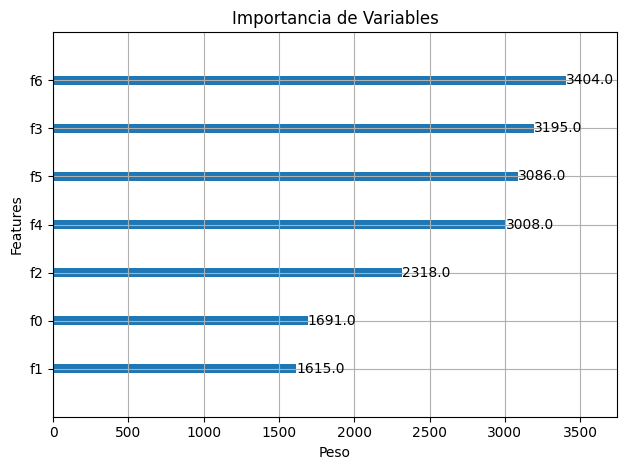

In [16]:
import matplotlib.pyplot as plt
import xgboost as xgb

# Crear el gráfico de importancia de características
xgb.plot_importance(xgb_model, importance_type='weight', max_num_features=10, title='Importancia de Variables', xlabel='Peso')
plt.tight_layout()
plt.show()

*XGBoost y Random Forest entregaron el mejor rendimiento. Sin embargo, el modelo tiene dificultades para predecir correctamente la clase 7 debido a la escasez de datos.*

**Se aplica SMOTE a XGBOOST para ver si el rendimiento del modelo mejora un poco más.**

In [18]:
# Aplicar SMOTE para balancear las clases
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Ajustar las clases para que comiencen desde 0
y_train_resampled -= 1  # Restar 1 para que las clases sean 0-7

# Reentrenar el modelo XGBoost con los datos balanceados
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train_resampled, y_train_resampled)

# Realizar predicciones en el conjunto de prueba (sin ajustar)
y_pred_xgb = xgb_model.predict(X_test)

# Ajustar las predicciones para que estén en el rango 1-8
y_pred_xgb += 1  # Volver a poner las predicciones en el rango 1-8

# Evaluar el modelo
from sklearn.metrics import classification_report, confusion_matrix
print("XGBoost con SMOTE - Clasificación")
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

# Guardar el modelo entrenado con SMOTE
import joblib
joblib.dump(xgb_model, 'xgboost_starcraft_model_smote.pkl')


[04/13/25 16:06:39] WARNING  C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\site-packag ]8;id=962102;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\warnings.py\warnings.py]8;;\:]8;id=698165;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\warnings.py#109\109]8;;\
                             es\xgboost\training.py:183: UserWarning: [16:06:39] WARNING:                          
                             C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738:                           
                             Parameters: { "use_label_encoder" } are not used.                                     
                                                                                                                   
                               bst.update(dtrain, iteration=i, fobj=obj)                                           
                                                                                                                   

XGBoost con SMOTE - Clasificación
[[13  7  5  4  1  1  0  0]
 [14 20 28 13  3  1  1  0]
 [ 5 13 39 40 13  2  0  0]
 [ 6 18 32 48 48 15  0  0]
 [ 1  1 16 40 49 45  6  0]
 [ 0  1  6 19 33 50  7  1]
 [ 0  0  0  0  1  3  0  0]
 [ 0  0  0  0  0  0  0 10]]
              precision    recall  f1-score   support

           1       0.33      0.42      0.37        31
           2       0.33      0.25      0.29        80
           3       0.31      0.35      0.33       112
           4       0.29      0.29      0.29       167
           5       0.33      0.31      0.32       158
           6       0.43      0.43      0.43       117
           7       0.00      0.00      0.00         4
           8       0.91      1.00      0.95        10

    accuracy                           0.34       679
   macro avg       0.37      0.38      0.37       679
weighted avg       0.34      0.34      0.34       679



['xgboost_starcraft_model_smote.pkl']

**Probamos otro modelo con GradientBoostingClassifier**

In [19]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Entrenar el modelo Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train_resampled, y_train_resampled)

# Predecir
y_pred_gb = gb_model.predict(X_test)

# Evaluar el modelo
print("Gradient Boosting - Clasificación")
print(confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

# Guardar el modelo entrenado con SMOTE
import joblib
joblib.dump(gb_model, 'gradient_boosting_starcraft_model_smote.pkl')


Gradient Boosting - Clasificación
[[ 0  0  0  0  0  0  0  0  0]
 [13 10  5  2  0  1  0  0  0]
 [20 20 25 12  3  0  0  0  0]
 [13 16 32 33 15  3  0  0  0]
 [ 8 20 36 33 44 24  2  0  0]
 [ 0  5 15 38 45 50  5  0  0]
 [ 0  0  8 14 27 54 14  0  0]
 [ 0  0  0  0  1  3  0  0  0]
 [ 0  0  0  0  0  0  0 10  0]]


[04/13/25 16:09:58] WARNING  C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\site-packag ]8;id=38252;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\warnings.py\warnings.py]8;;\:]8;id=486394;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\warnings.py#109\109]8;;\
                             es\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning:                   
                             Precision is ill-defined and being set to 0.0 in labels with no                       
                             predicted samples. Use `zero_division` parameter to control this                      
                             behavior.                                                                             
                               _warn_prf(average, modifier, f"{metric.capitalize()} is",                           
                             len(result))                                                                          
                                                                                                                   

                    WARNING  C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\site-packag ]8;id=789960;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\warnings.py\warnings.py]8;;\:]8;id=173244;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\warnings.py#109\109]8;;\
                             es\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning:                   
                             Recall is ill-defined and being set to 0.0 in labels with no true                     
                             samples. Use `zero_division` parameter to control this behavior.                      
                               _warn_prf(average, modifier, f"{metric.capitalize()} is",                           
                             len(result))                                                                          
                                                                                                                   

                    WARNING  C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\site-packag ]8;id=850618;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\warnings.py\warnings.py]8;;\:]8;id=22325;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\warnings.py#109\109]8;;\
                             es\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning:                   
                             Precision is ill-defined and being set to 0.0 in labels with no                       
                             predicted samples. Use `zero_division` parameter to control this                      
                             behavior.                                                                             
                               _warn_prf(average, modifier, f"{metric.capitalize()} is",                           
                             len(result))                                                                          
                                                                                                                   

                    WARNING  C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\site-packag ]8;id=103092;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\warnings.py\warnings.py]8;;\:]8;id=209309;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\warnings.py#109\109]8;;\
                             es\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning:                   
                             Recall is ill-defined and being set to 0.0 in labels with no true                     
                             samples. Use `zero_division` parameter to control this behavior.                      
                               _warn_prf(average, modifier, f"{metric.capitalize()} is",                           
                             len(result))                                                                          
                                                                                                                   

                    WARNING  C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\site-packag ]8;id=690176;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\warnings.py\warnings.py]8;;\:]8;id=704340;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\warnings.py#109\109]8;;\
                             es\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning:                   
                             Precision is ill-defined and being set to 0.0 in labels with no                       
                             predicted samples. Use `zero_division` parameter to control this                      
                             behavior.                                                                             
                               _warn_prf(average, modifier, f"{metric.capitalize()} is",                           
                             len(result))                                                                          
                                                                                                                   

                    WARNING  C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\site-packag ]8;id=521784;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\warnings.py\warnings.py]8;;\:]8;id=170489;file://C:\Users\matia\AppData\Local\Programs\Python\Python310\lib\warnings.py#109\109]8;;\
                             es\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning:                   
                             Recall is ill-defined and being set to 0.0 in labels with no true                     
                             samples. Use `zero_division` parameter to control this behavior.                      
                               _warn_prf(average, modifier, f"{metric.capitalize()} is",                           
                             len(result))                                                                          
                                                                                                                   

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.14      0.32      0.20        31
           2       0.21      0.31      0.25        80
           3       0.25      0.29      0.27       112
           4       0.33      0.26      0.29       167
           5       0.37      0.32      0.34       158
           6       0.67      0.12      0.20       117
           7       0.00      0.00      0.00         4
           8       0.00      0.00      0.00        10

    accuracy                           0.26       679
   macro avg       0.22      0.18      0.17       679
weighted avg       0.35      0.26      0.27       679



['gradient_boosting_starcraft_model_smote.pkl']

In [8]:
print(df.columns)


Index(['GameID', 'Age', 'HoursPerWeek', 'TotalHours', 'APM', 'SelectByHotkeys',
       'AssignToHotkeys', 'MinimapAttacks', 'MinimapRightClicks',
       'NumberOfPACs', 'GapBetweenPACs', 'ActionLatency', 'ActionsInPAC',
       'TotalMapExplored', 'WorkersMade', 'UniqueUnitsMade',
       'ComplexUnitsMade', 'ComplexAbilityUsed', 'MaxTimeStamp',
       'LeagueIndex_1', 'LeagueIndex_2', 'LeagueIndex_3', 'LeagueIndex_4',
       'LeagueIndex_5', 'LeagueIndex_6', 'LeagueIndex_7', 'LeagueIndex_8'],
      dtype='object')
